<center><span style="font-size:50px;"><b>ANALYSIS OF CUTS ON MC - PAIR VARIABLES</b></span></center>

In this notebook we want to search for the best cuts of the Monte Carlo data, in order to try them later in real data.  
Here we focus in the distribution and possible cuts of the pair variables.

The codes in the pdg for the important particles are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

---

---

<center><span style="font-size:35px;"><b>UPLOADING DATA</b></span></center>

#### ALL OUR DATA

In [2]:
# %%bash
# ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

#### UPLOAD DATA
Let's upload the data while:
* ignoring useless columns ("neg_pt", "pos_pt")
* substituting (or rather summarizing them) the columns of MC info with a single column telling us who is D0 (1), who anti-D0 (-1) and who background (0)

In [3]:
# directory where the files are stored
folder = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"
all_files = glob.glob(os.path.join(folder, "*.pkl"))
# choose eventually which columns to exclude:
useless_cols = ["neg_pt", "pos_pt"]

# choose how many files to load
x = 53                              # change this to the number of files you want (or your RAM can afford..)
files_to_load = all_files[:x]

print(f"Found {len(all_files)} files. Loading up to {len(files_to_load)} files")

Found 57 files. Loading up to 53 files


In [4]:
# initialization
final_results = pd.DataFrame()

# UPLOAD ---------------------------------------------------------------------
for i, f in enumerate(files_to_load, start=1):
    
    # UPLOAD DATA excluding useless columns:
    df = pd.read_pickle(f)
    df = df.drop(columns=useless_cols)

    # DEFINING MASKS to decrease the number of columns by summarizing them:
    mask_true_d0 = (
        (df["track_pdg_pos"] == 211 ) &
        (df["track_pdg_neg"] == -321 ) &
        (df["mother_pdg_pos"] == 421) &
        (df["mother_pdg_neg"] == 421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_true_anti_d0 = (
        (df["track_pdg_pos"] == 321) &
        (df["track_pdg_neg"] == -211) &
        (df["mother_pdg_pos"] == -421) &
        (df["mother_pdg_neg"] == -421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2) &
        (df['mother_orig_ind_pos'] == df['mother_orig_ind_neg'] )
    )
    mask_background = ( (~mask_true_d0) & (~mask_true_anti_d0) )

    # SUMMARIZE some columns:
    df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0] , [1, -1], default=0)
    summarized_cols = ["track_pdg_pos", "track_pdg_neg", "mother_pdg_pos", "mother_pdg_neg", "beauty_pdg_pos", "beauty_pdg_neg",
                     "mother_N_final_state_pos", "mother_N_final_state_neg", "mother_orig_ind_pos", "mother_orig_ind_neg"]
    df = df.drop(columns=summarized_cols)

    # FINAL single file uploaded:
    final_results = pd.concat([final_results, df], ignore_index=True)
    
    # free memory
    del df
    gc.collect()
    
    # debug
    print(f"{i}", end=' ')

print(f"\nFinished: loaded {i} files out of {len(all_files)} available.")

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 
Finished: loaded 53 files out of 57 available.


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 46_033_111 rows and 17 columns.
It occupies 5_970.48 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_TPCka,neg_TOFka,neg_fDcaXY,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,truth
0,-1.306505e-03,1.647857,1.449501,1.590537,2.064567,0.378364,-6.947757,133.719315,-0.093189,-1.825205,6352.559082,0.014020,0.260088,951.74823,-0.417602,587.019836,0
1,-7.080836e-03,0.947897,0.935076,0.698830,5.386100,-0.238735,-6.947757,133.719315,-0.093189,-0.913118,-1072.173340,0.075984,0.260088,951.74823,-6.905696,-147.886261,0
2,5.584245e-03,0.813485,0.819674,0.772823,3.091237,0.265503,-6.947757,133.719315,-0.093189,1.178568,-999.000000,-0.059924,0.260088,951.74823,-6.446581,-999.000000,0
3,-1.640872e-02,0.966982,0.953821,0.597828,3.955609,-0.544734,-6.947757,133.719315,-0.093189,69.200188,-999.000000,0.176080,0.260088,951.74823,24.368649,-999.000000,0
4,1.596988e-02,1.400717,1.328300,0.452560,3.330226,0.408916,-6.947757,133.719315,-0.093189,-0.713104,-999.000000,-0.171371,0.260088,951.74823,-2.782018,-999.000000,0
46033106,1.809366e-05,0.999230,0.960636,0.085276,0.044543,-0.182973,-9.868178,-999.000000,-0.002902,1.928843,-999.000000,-0.006235,1.425067,-999.00000,-7.685923,-999.000000,0
46033107,2.383902e-06,0.929269,0.921494,0.413874,0.003412,-0.391380,-8.716123,-999.000000,-0.001018,-2.551108,-999.000000,-0.002343,1.152861,-999.00000,-9.076614,-999.000000,0
46033108,-1.839993e-06,1.201399,1.046106,1.098163,0.004124,-0.608493,-8.716123,-999.000000,-0.001018,-0.073063,-999.000000,0.001808,1.152861,-999.00000,-0.479318,-999.000000,0
46033109,2.385883e-06,1.394139,1.251744,1.412289,0.027997,-0.962548,-6.620672,-39.502575,-0.006721,0.499645,-999.000000,-0.000355,0.061005,0.16194,1.409692,-999.000000,0
46033110,3.097834e-07,1.705106,1.633905,0.444067,0.062278,0.307378,-3.261019,-999.000000,-0.000873,0.499645,-999.000000,-0.000355,-0.082602,-999.00000,1.409692,-999.000000,0


---

## TRUE $D_0$ IN OUR DATA

In [6]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

In [7]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       8590
Number of anti-D0:  9058
Number of background pairs: 46_015_463
Fraction of D0 and anti-D0 over total: 0.0383%


The variables we have to work with are:

In [8]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY', 'pos_TPCpi',
       'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi', 'neg_TOFpi', 'pos_TPCka',
       'pos_TOFka', 'truth'],
      dtype='object')


Example: the variable 'neg_TOFka' refers to the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which is a $K^-$ for the $D^0$ case, a $\pi^-$ for the $anti-D^0$ case, and something else in background case.

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS PLOT</b></span></center>

We now plot the data, remembering to plot both the columns for mass and anti-mass because we want to include the reflex component.

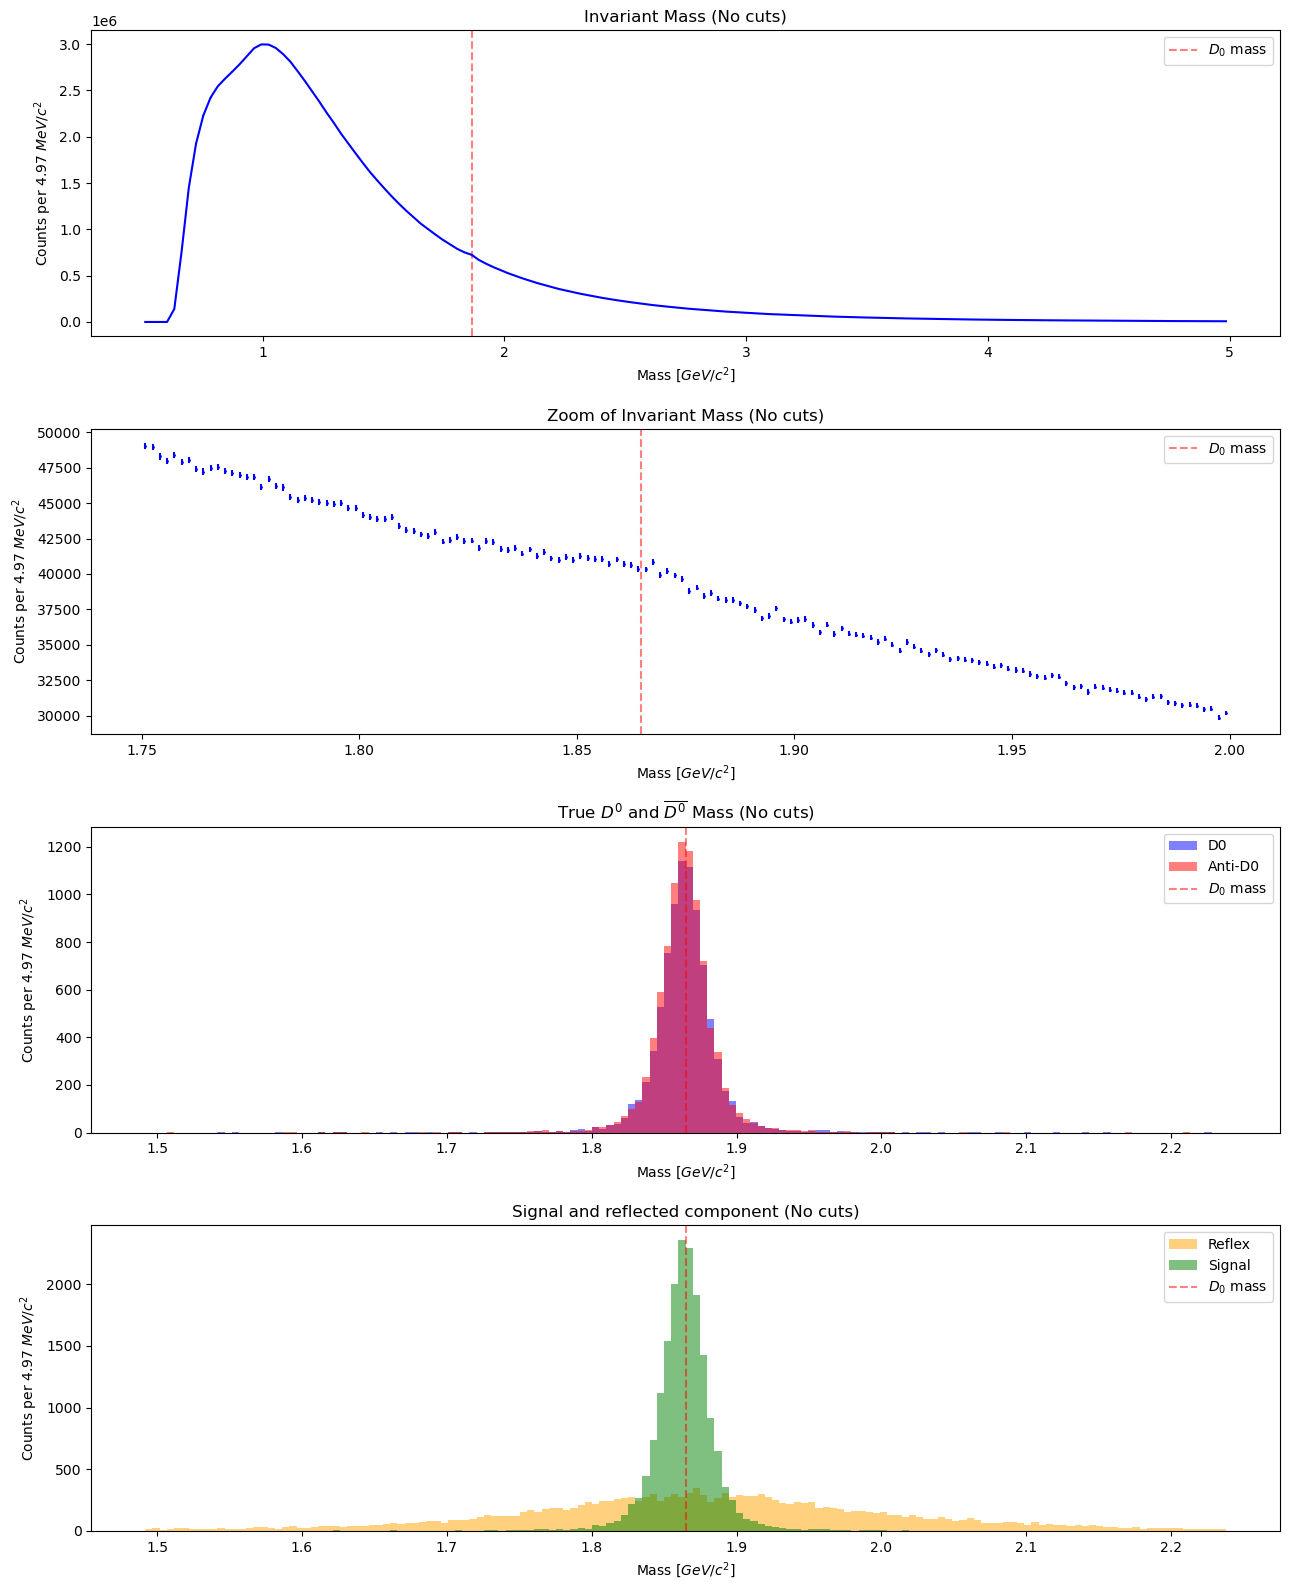

In [9]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 150

num_of_plots = 4
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,4*num_of_plots)  )

# GLOBAL PLOT ---------------------------------------- 
data = np.concatenate([final_results["inv_mass"].values, final_results["anti_mass"].values])
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(0.5, 5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs[0].errorbar(bin_centers, counts, yerr=errors, fmt='-', markersize=2, color='blue')
axs[0].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No cuts)")
axs[0].legend()


# ZOOM OF GLOBAL PLOT ---------------------------------------- 
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(1.75, 2))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)
axs[1].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("Zoom of Invariant Mass (No cuts)")
axs[1].legend()

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO ---------------------------------------- 
data = final_results.loc[mask_true_d0, "inv_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = final_results.loc[mask_true_anti_d0, "anti_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title(r"True $D^0$ and $\overline{{D^0}}$ Mass (No cuts)")
axs[2].legend()
#axs[2].set_xticks( np.arange(1.6, 2.2, 0.05) )

#  ---------------------------------------- 
# PLOTTING signal (D0 mass + anti-D0 anti-mass) reflex component (D0 anti-mass + anti-D0 mass)
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
axs[3].hist( reflex_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="orange", alpha=0.5, label="Reflex")
axs[3].hist( signal_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="green", alpha=0.5, label="Signal")
axs[3].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs[3].set_xlabel("Mass [$GeV/c^2$]")
axs[3].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[3].set_title(r"Signal and reflected component (No cuts)")
axs[3].legend()



del data
#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.  

Also the distribution of $D_0$ and $anti-D_0$ is almost the same.

---

### APPLYING SINGLE TRACK VARIABLES CUTS

Search for best cuts done in the single tracks notebook:
```
Best cuts found:
TOFka_neg: ±7.57
TPCka_neg: ±5.43
TOFka_pos: ±8.36
TPCka_pos: ±6.43
Maximum significance S/√(S+B): 9.7703
```

In [10]:
# single cuts:
cut_neg_TOFka = 7.57
cut_neg_TPCka = 5.43
cut_pos_TOFka = 8.36
cut_pos_TPCka = 6.43


# we create the cuts as a mask:
cuts = (
        ( (final_results['neg_TOFka'] > -cut_neg_TOFka) & (final_results['neg_TOFka'] < cut_neg_TOFka) &
          (final_results['neg_TPCka'] > -cut_neg_TPCka) & (final_results['neg_TPCka'] < cut_neg_TPCka) )
        |
        ( (final_results['pos_TOFka'] > -cut_pos_TOFka) & (final_results['pos_TOFka'] < cut_pos_TOFka) &
          (final_results['pos_TPCka'] > -cut_pos_TPCka) & (final_results['pos_TPCka'] < cut_pos_TPCka) )
)


In [11]:
final_results = final_results[ cuts ]

---

---

---

<center><span style="font-size:35px;"><b>PAIR VARIABLES DISTRIBUTION</b></span></center>

## DEFINING $p_t$ WINDOWS
We want now to create the masks for the various $p_t$ slices, in order to better see the signal for each $p_t$ interval: 0-1,1-2,2-3,3-5,5-8,8-16.

In [12]:
multiple_masks_pt = [ 
    final_results["pt"].between(0, 1.5), 
    final_results["pt"].between(1.5, 3),
    final_results["pt"].between(3, 8), 
    final_results["pt"].between(8, 16)
]

pt_windows = [ "0-1.5", "1.5-3", "3-8", "8-16" ]

# let's count signal and background for each pT window
signal_tot_per_pt = []
num_bg_pairs_per_pt = []

for mask_pt in multiple_masks_pt:

    # count signal for each pT window
    signal_tot = len(final_results.loc[mask_signal & mask_pt, "truth"])
    signal_tot_per_pt.append(signal_tot)

    # count background for each pT window
    bg_tot = len(final_results.loc[mask_background & mask_pt, "truth"])
    num_bg_pairs_per_pt.append(bg_tot)

## POYNTING ANGLE in $p_T$ slices

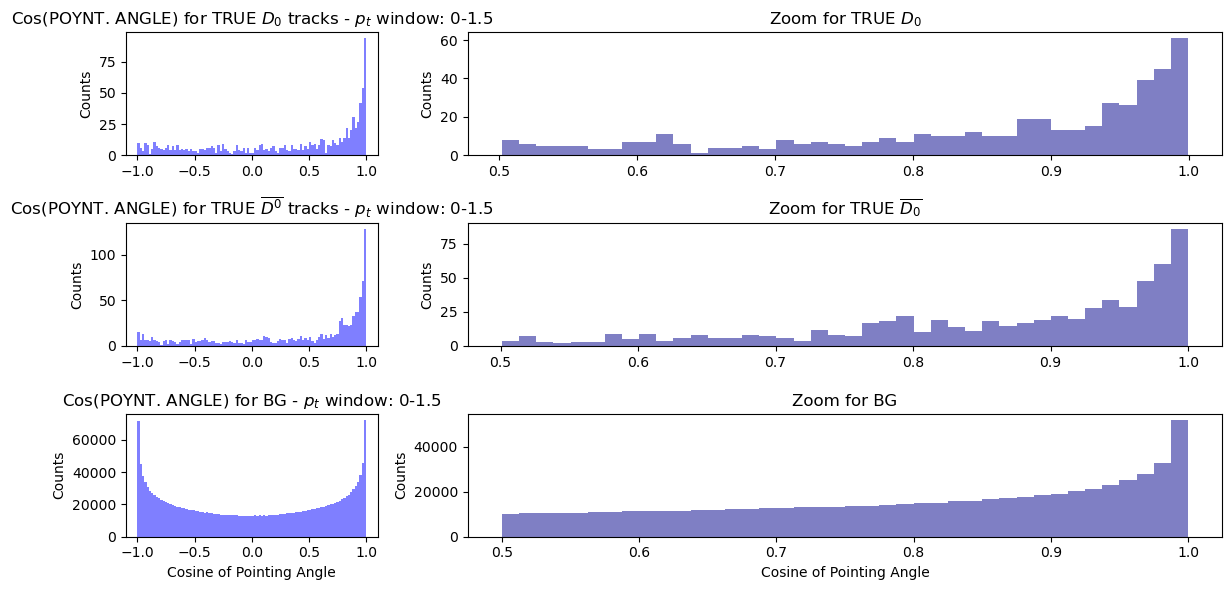

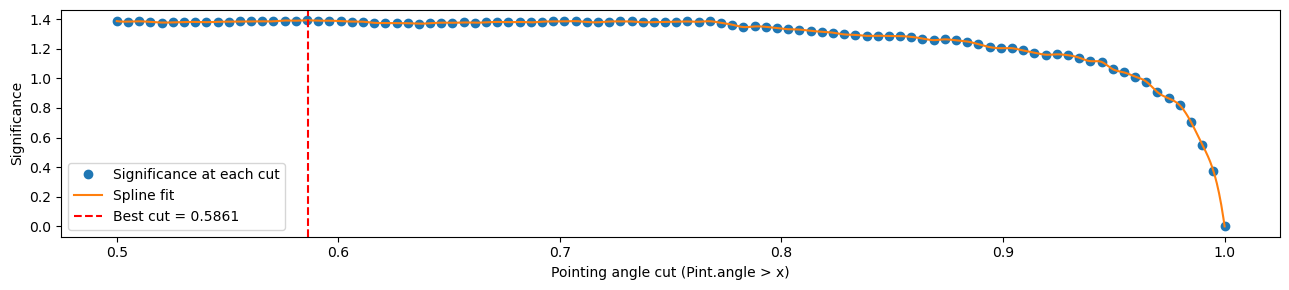

Best cut: cos(pointing) > 0.5861
With this cut we keep 54.51% of original signal
With this cut we keep 28.76% of background pairs


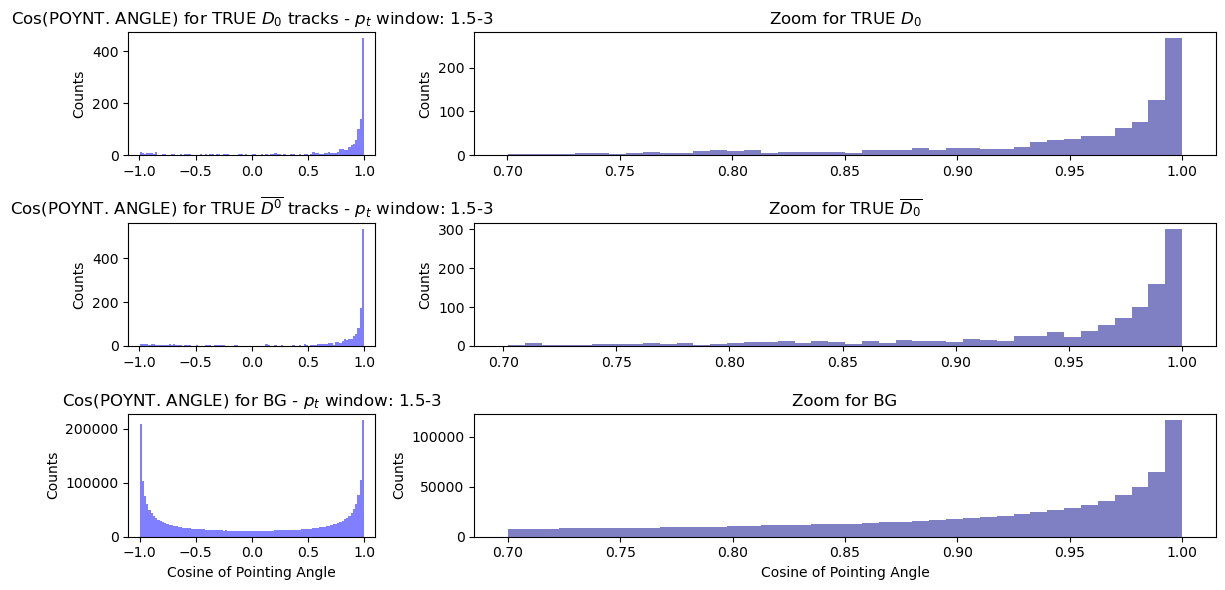

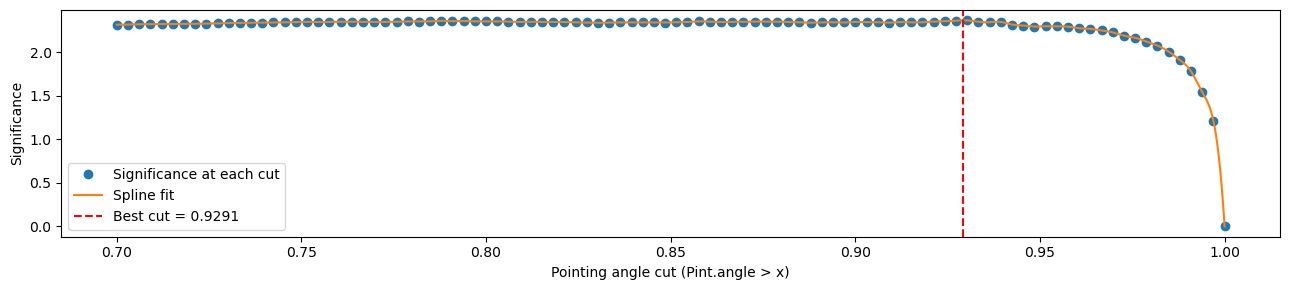

Best cut: cos(pointing) > 0.9291
With this cut we keep 56.78% of original signal
With this cut we keep 17.08% of background pairs


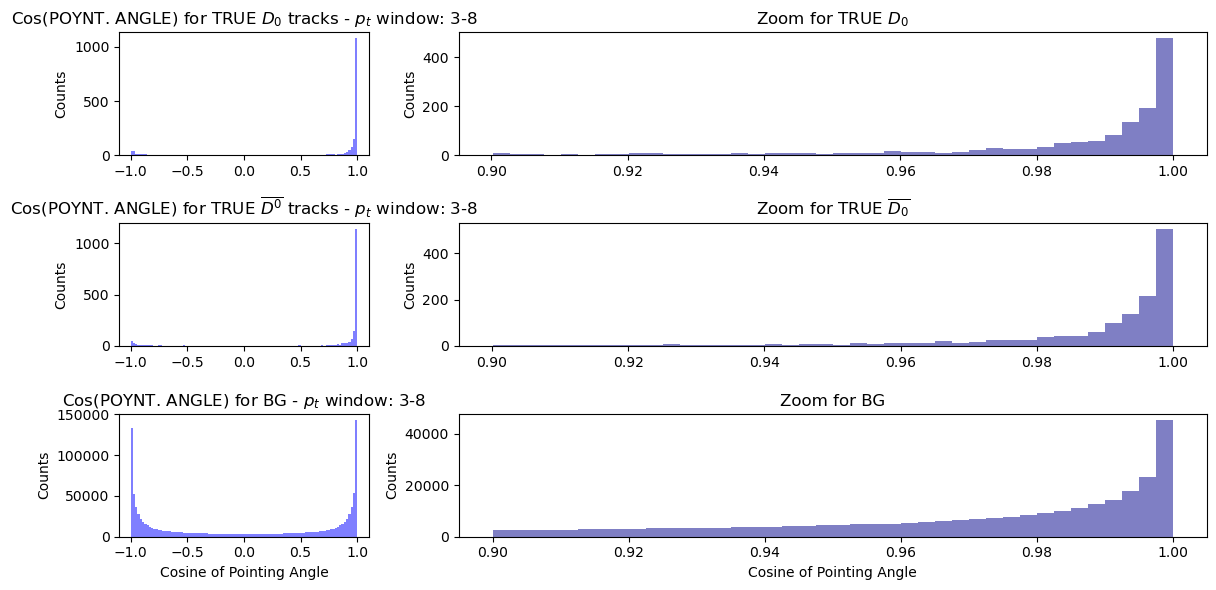

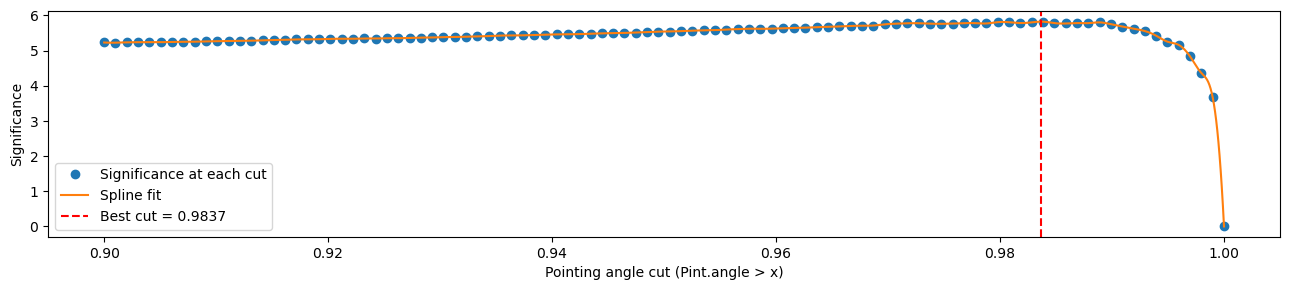

Best cut: cos(pointing) > 0.9837
With this cut we keep 58.44% of original signal
With this cut we keep 11.88% of background pairs


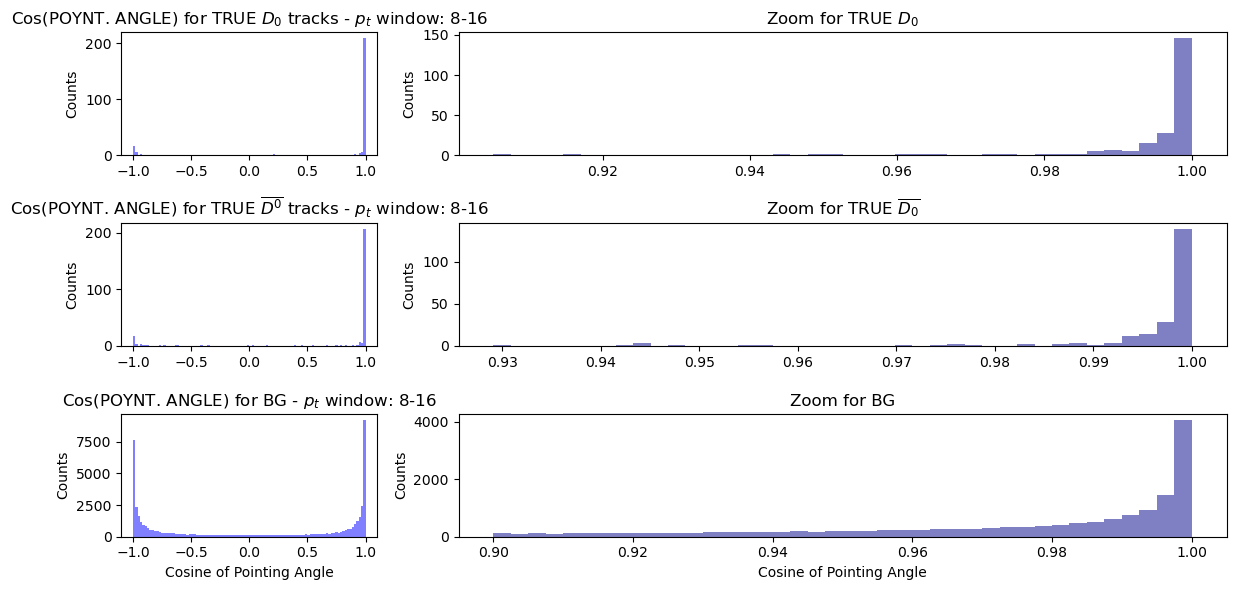

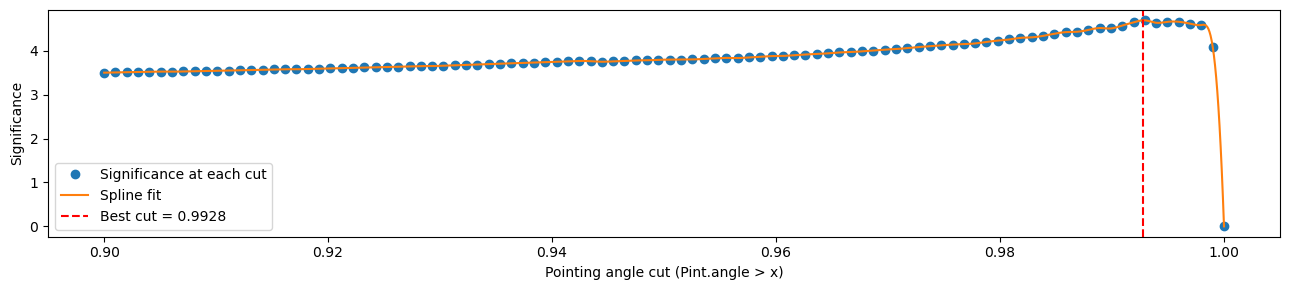

Best cut: cos(pointing) > 0.9928
With this cut we keep 72.54% of original signal
With this cut we keep 12.73% of background pairs


In [13]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )
    # meaningful cut for the zoom, depending on the pt slice we are in:
    match i:   # this command is like the usual "switch" in other languages
        case 0: cut = 0.5
        case 1: cut = 0.7
        case _: cut = 0.9
    
    # --- Plot cosine of poynting angle FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'cos_pointing'].values
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"Cos(POYNT. ANGLE) for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ data > cut ]
    axes["zoom_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot cosine of poynting angle FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'cos_pointing'].values
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"Cos(POYNT. ANGLE) for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ data > cut ]
    axes["zoom_anti_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title("Zoom for TRUE $\overline{D_0}$")
    
    # --- Plot cosine of poynting angle FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'cos_pointing'].values
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("Cosine of Pointing Angle")
    axes["total_all"].set_title(r"Cos(POYNT. ANGLE) for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ data > cut ]
    axes["zoom_all"].hist( data, bins=40, color="darkblue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("Cosine of Pointing Angle")
    axes["zoom_all"].set_title("Zoom for BG")
    
    plt.tight_layout()
    plt.show()
    del data
    
    # --------------------- SEARCH FOR BEST CUT ----------------------------------------------
    # meaningful values for x axis, depending on the pt slice we are in:
    match i: 
        case 0 | 1: x_val = np.linspace(cut , 1, 100)     # case for i=0 or i=1
        case _: x_val = np.linspace( 0.9 , 1, 100)
    y_val =[]       # this will save the significance value for each cut
    
    signal_pointing = final_results.loc[ mask_pt & mask_signal, 'cos_pointing'].values
    background_pointing = final_results.loc[ mask_pt & mask_background, 'cos_pointing'].values
    
    for x in x_val:
        numerator = np.sum(signal_pointing > x)
        denominator = np.sum(background_pointing > x)
        total = numerator + denominator
        if total == 0:  y_val.append(0)   # significance is zero if no events survive
        else:           y_val.append(numerator / np.sqrt(total))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                  # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]     # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('Pointing angle cut (Pint.angle > x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # PRINT results:
    print(f"Best cut: cos(pointing) > {best_cut:.4f}")
    print(f"With this cut we keep {len( signal_pointing[ signal_pointing>best_cut ] )/signal_tot_per_pt[i]*100:.2f}% of original signal")
    print(f"With this cut we keep {len( background_pointing[ background_pointing>best_cut ] )/num_bg_pairs_per_pt[i]*100:.2f}% of background pairs")
    

## dcaXY PRODUCT in $p_T$ slices

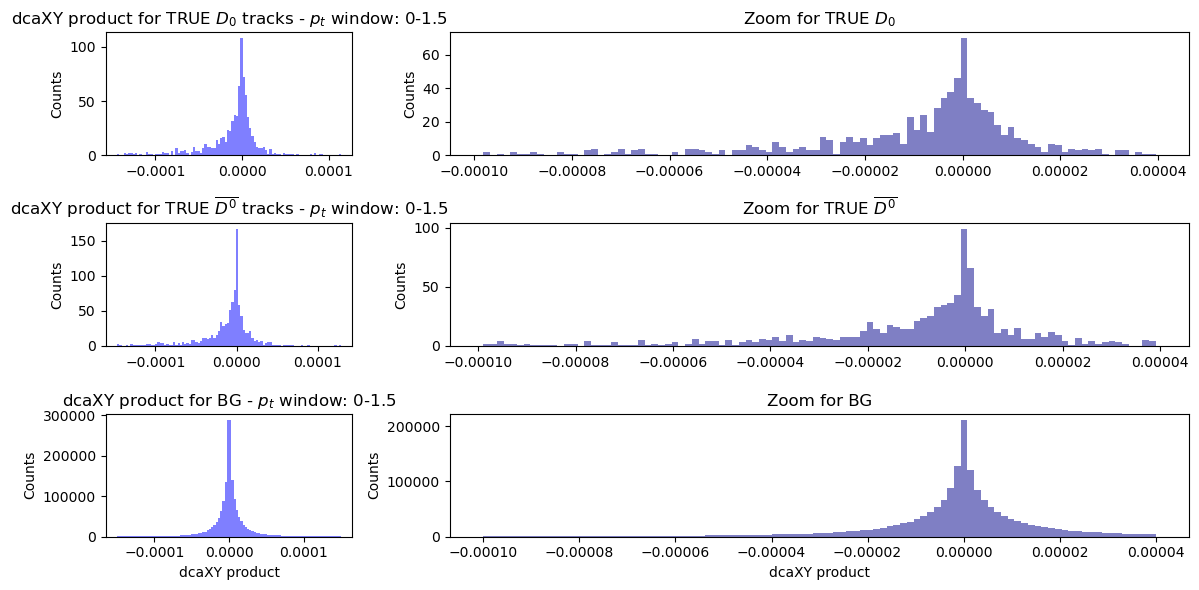

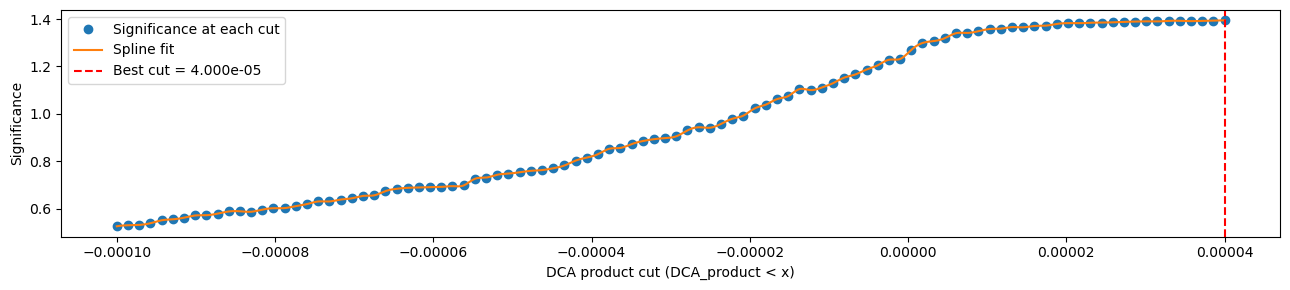

Best cut: (dcaXY product) < 4.000e-05
With this cut we keep 96.32% of original signal
With this cut we keep 89.54% of background pairs


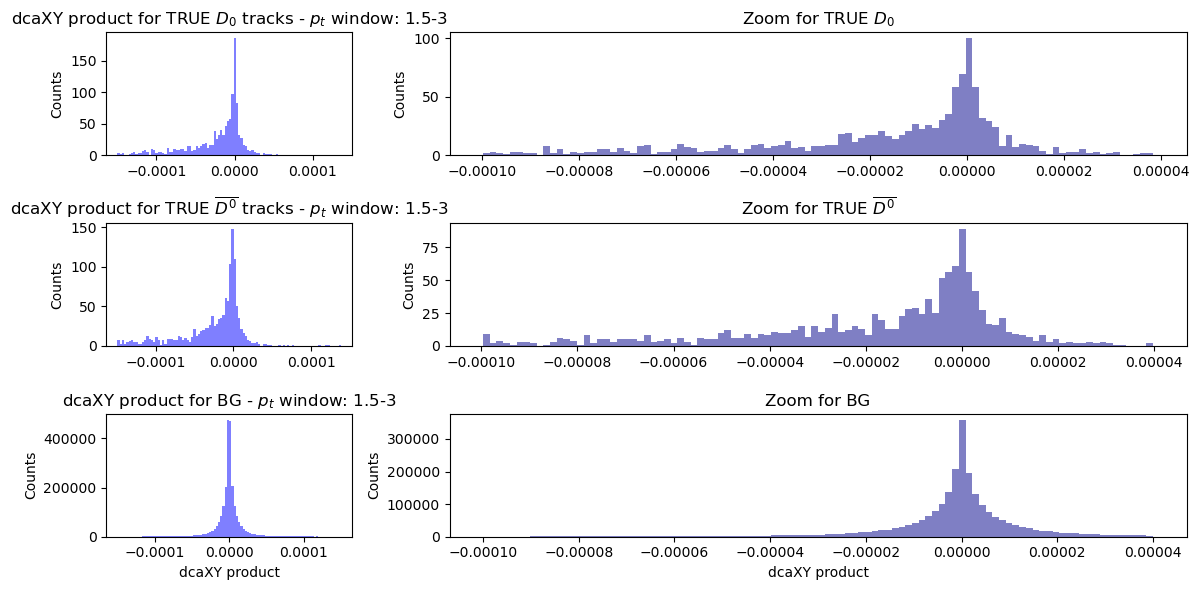

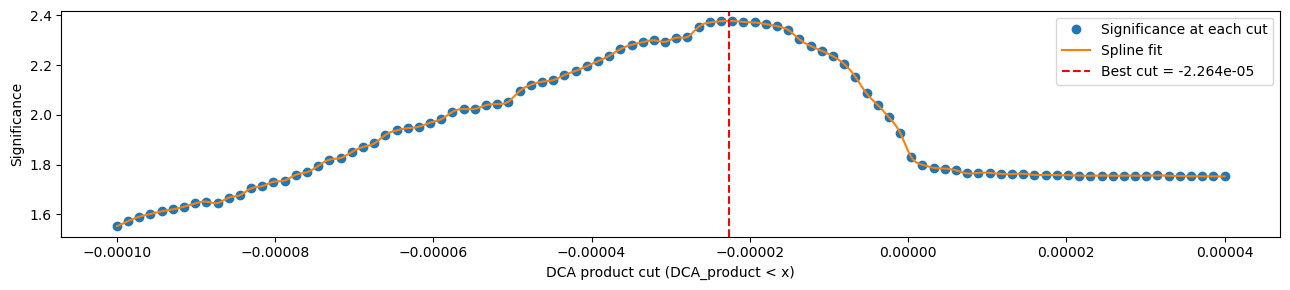

Best cut: (dcaXY product) < -2.264e-05
With this cut we keep 41.87% of original signal
With this cut we keep 9.18% of background pairs


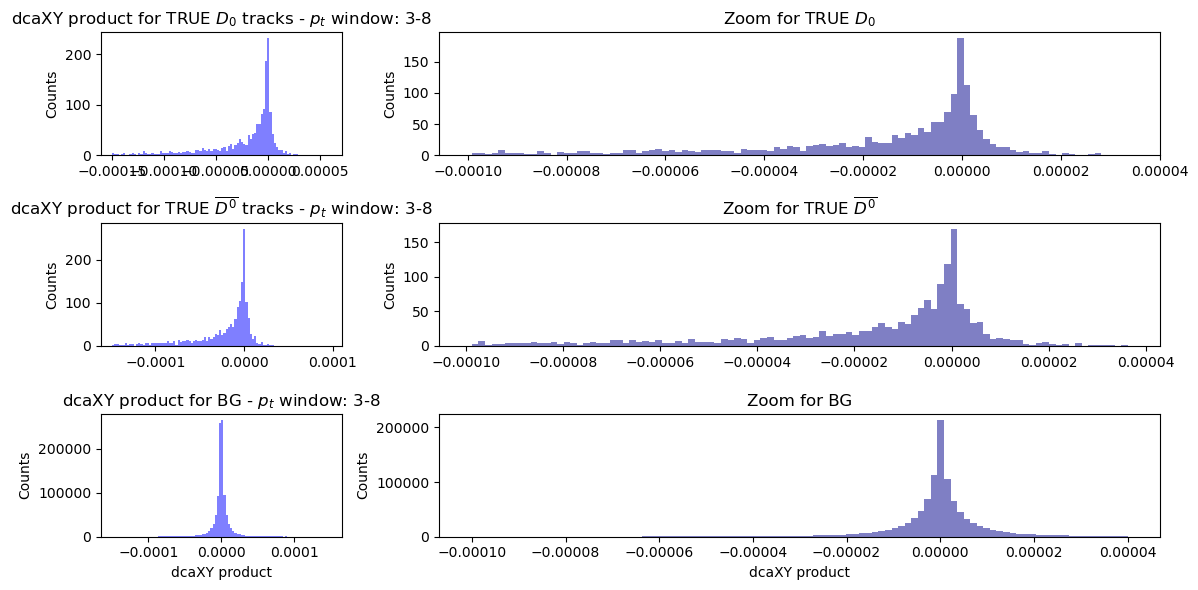

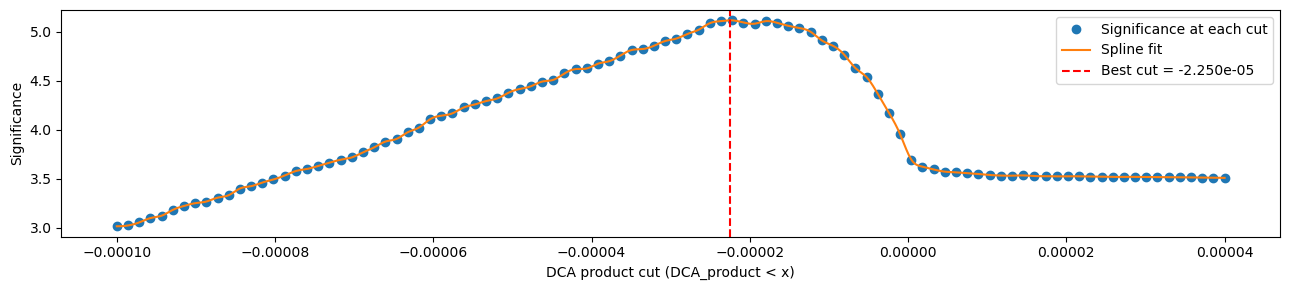

Best cut: (dcaXY product) < -2.250e-05
With this cut we keep 36.53% of original signal
With this cut we keep 6.07% of background pairs


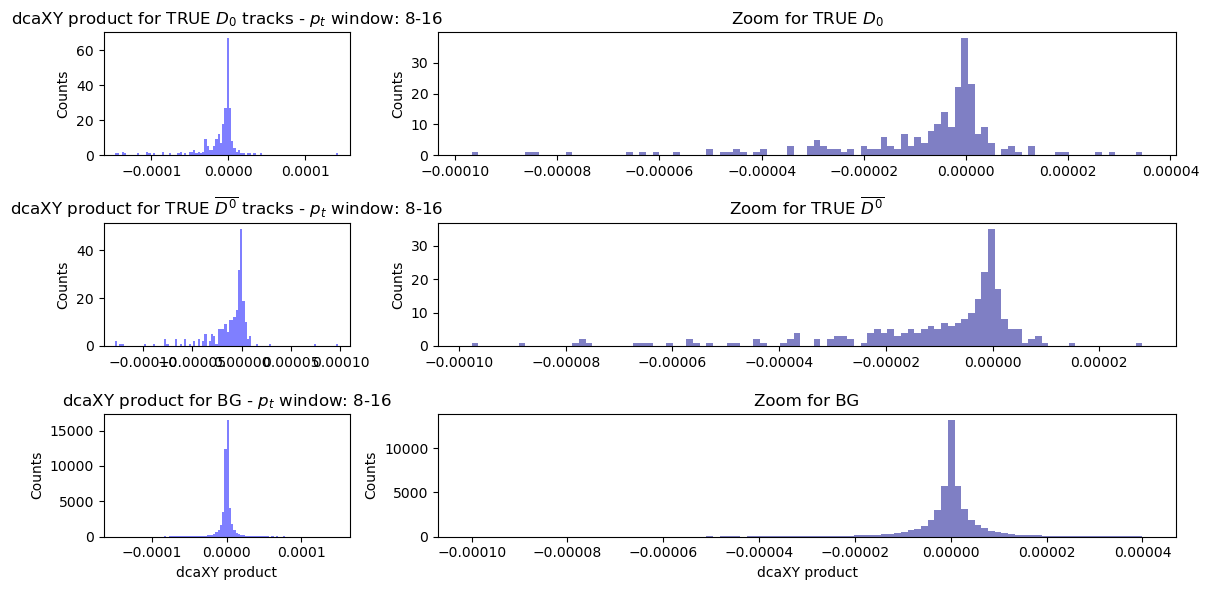

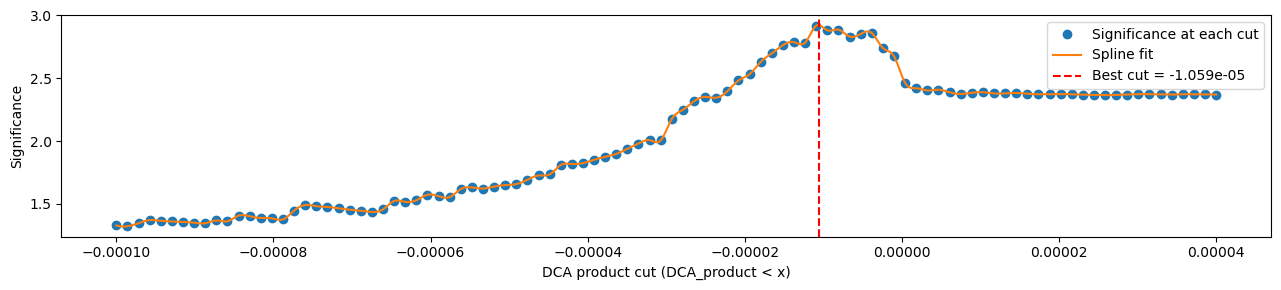

Best cut: (dcaXY product) < -1.059e-05
With this cut we keep 37.50% of original signal
With this cut we keep 8.95% of background pairs


In [14]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )
    # let's define the zoom cut:
    cut_inf = 0.0001
    cut_sup = 0.00004
    
    # --- Plot dcaXY product FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"dcaXY product for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot dcaXY product FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"dcaXY product for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))    
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_anti_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title(r"Zoom for TRUE $\overline{D^0}$")
    
    # --- Plot dcaXY product FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'dcaXY_product'].values
    data = data[ (data > -0.00015) & (data < 0.00015) ]
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("dcaXY product")
    axes["total_all"].set_title(r"dcaXY product for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ (data > -cut_inf) & (data < cut_sup) ]
    axes["zoom_all"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("dcaXY product")
    axes["zoom_all"].set_title("Zoom for BG")
    
    plt.tight_layout()
    plt.show()
    del data


    # --------------- SEARCH FOR BEST CUT IN DCA PRODUCT -------------------------------
    x_val = np.linspace( -0.0001, 0.00004, 100)
    y_val =[]                 # this will save the significance value for each cut
    
    signal_dca_prod = final_results.loc[ mask_pt & mask_signal, 'dcaXY_product'].values
    background_dca_prod = final_results.loc[ mask_pt & mask_background, 'dcaXY_product'].values
    
    for x in x_val:
        numerator = len( signal_dca_prod[ signal_dca_prod<x ] )
        denominator = len( background_dca_prod[ background_dca_prod<x ] )
        y_val.append(numerator / np.sqrt(numerator + denominator))
    
    # INTERPOLATION with spline:
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)                 # drawing the spline
    best_cut = x_dense[np.argmax(y_dense)]    # saving the cut that gives highest significance
    
    # PLOT:
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.3e}')
    ax.set_xlabel('DCA product cut (DCA_product < x)')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # PRINT results:
    print(f"Best cut: (dcaXY product) < {best_cut:.3e}")
    print(f"With this cut we keep {len( signal_dca_prod[ signal_dca_prod<best_cut ] )/signal_tot_per_pt[i]*100:.2f}% of original signal")
    print(f"With this cut we keep {len( background_dca_prod[ background_dca_prod<best_cut ] )/num_bg_pairs_per_pt[i]*100:.2f}% of background pairs")
  

## DECAY LENGTH in $p_T$ slices

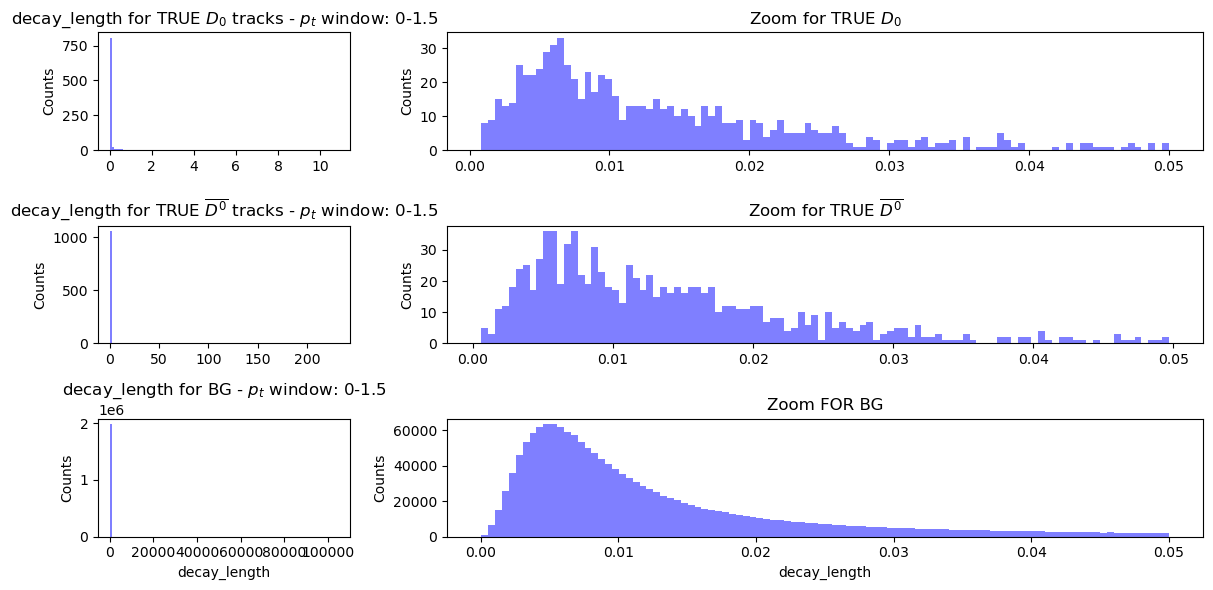

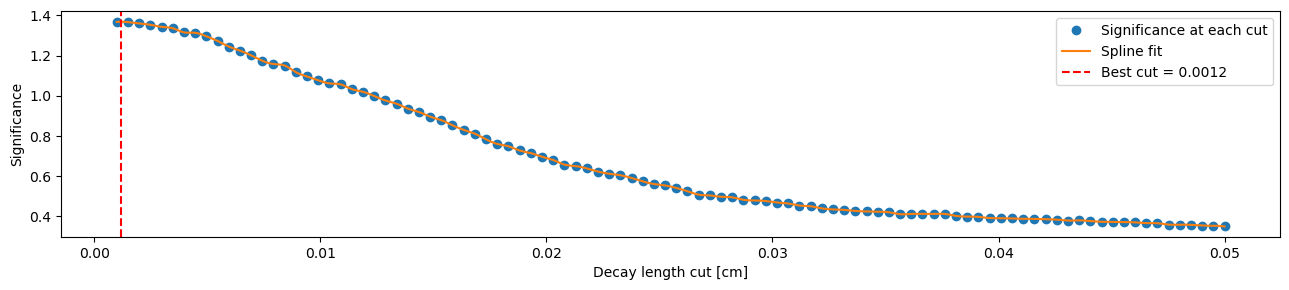

Best cut: (decay_length) > 0.0012
With this cut we keep 99.43% of the original signal
With this cut we keep 99.46% of the background pairs


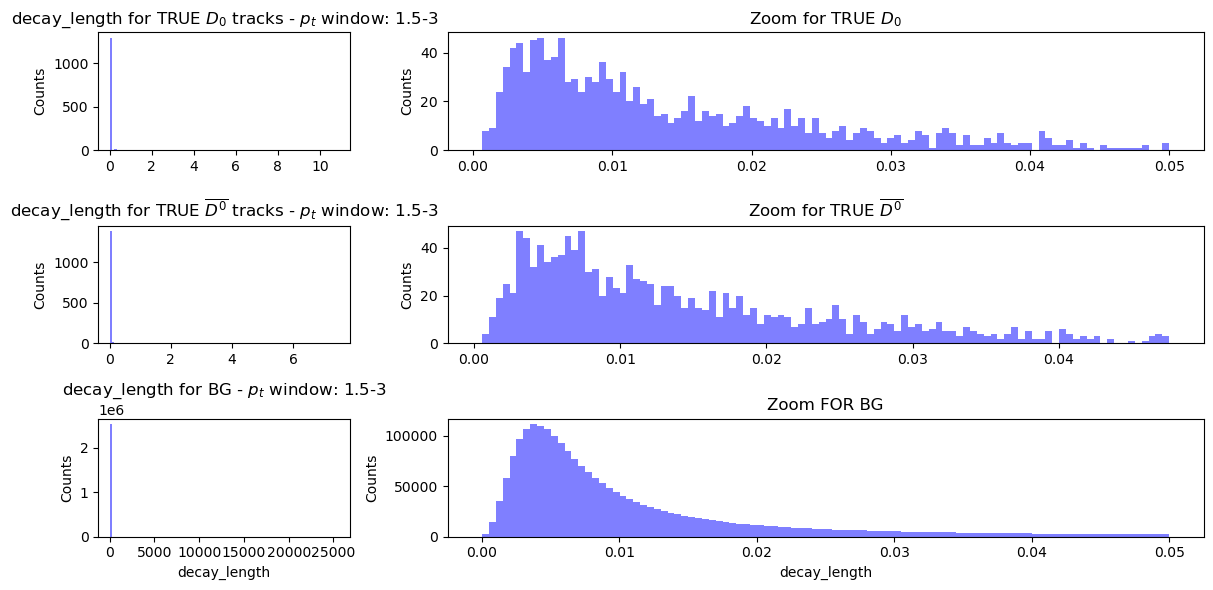

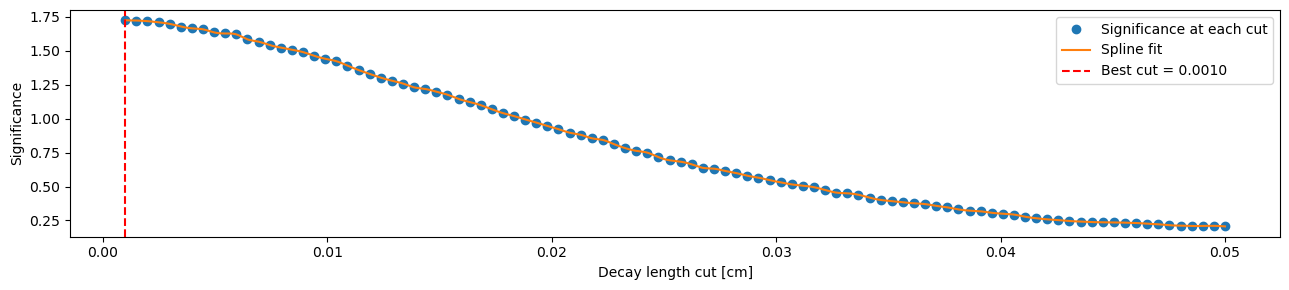

Best cut: (decay_length) > 0.0010
With this cut we keep 99.71% of the original signal
With this cut we keep 99.37% of the background pairs


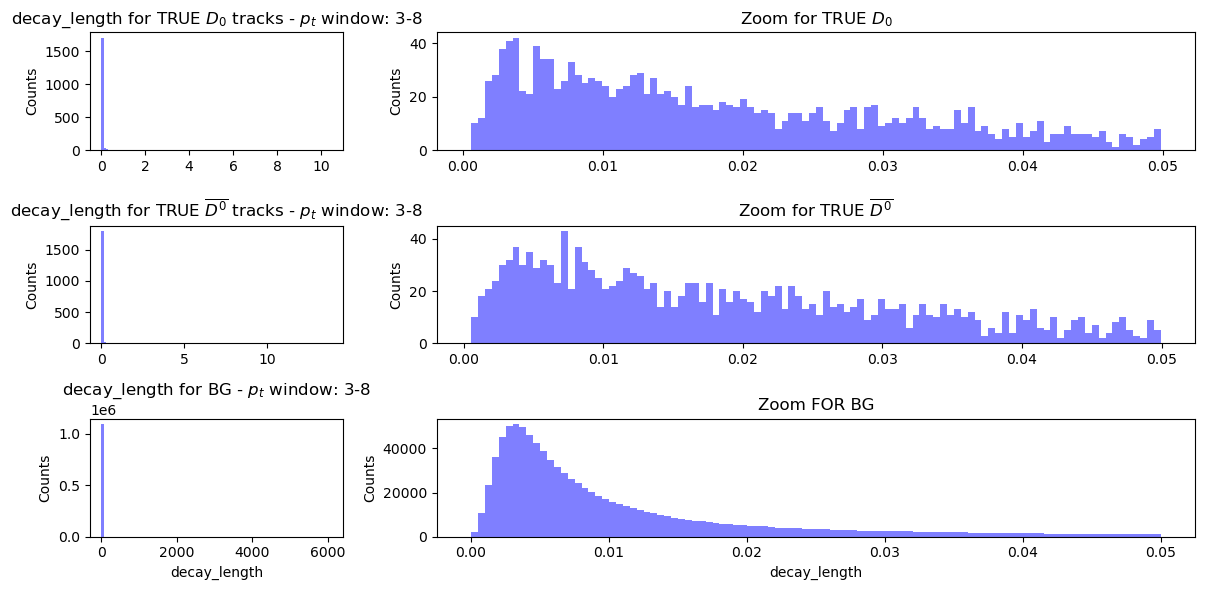

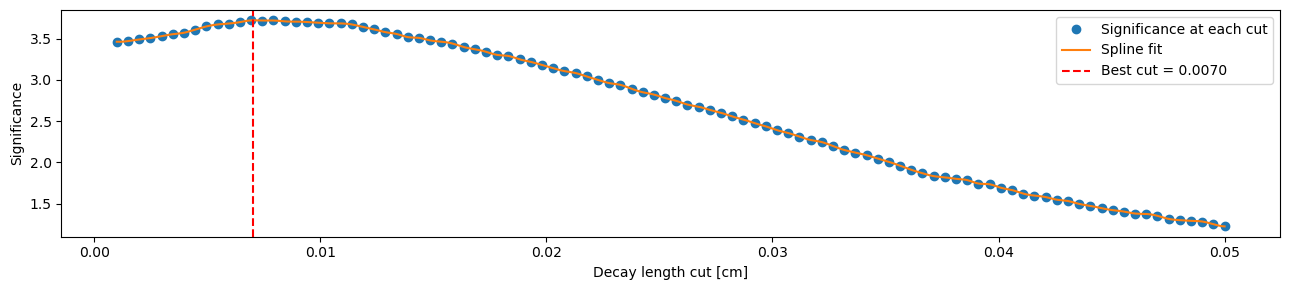

Best cut: (decay_length) > 0.0070
With this cut we keep 79.80% of the original signal
With this cut we keep 55.09% of the background pairs


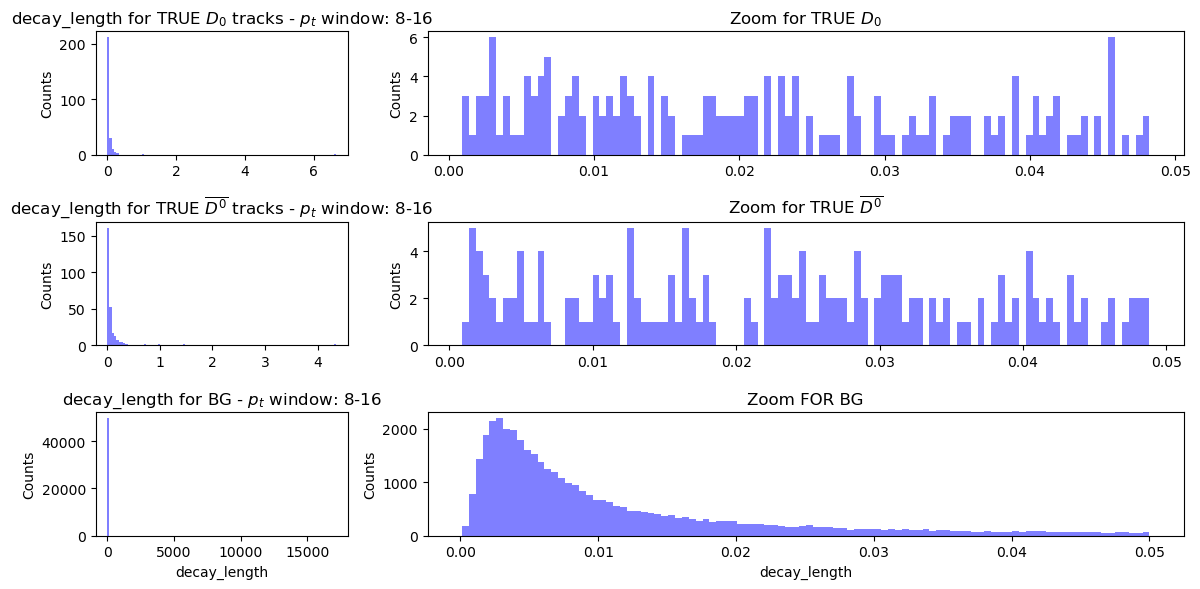

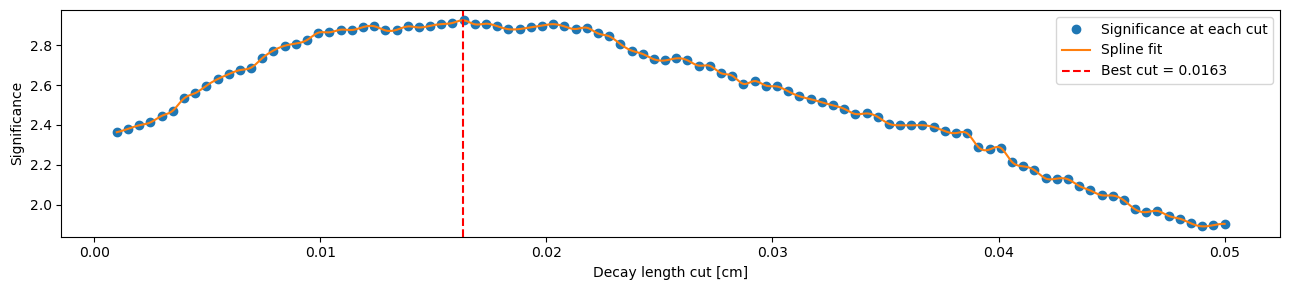

Best cut: (decay_length) > 0.0163
With this cut we keep 73.67% of the original signal
With this cut we keep 34.77% of the background pairs


In [15]:
N_BINS = 100

for i, mask_pt in enumerate(multiple_masks_pt):
    # Layout con due colonne
    zones = [
        ["total_D0", "zoom_D0"],
        ["total_anti_D0", "zoom_anti_D0"],
        ["total_all", "zoom_all"],
    ]
    
    # Creazione della figura usando subplot_mosaic
    fig, axes = plt.subplot_mosaic(
        zones,
        figsize=(12, 6),
        gridspec_kw={"width_ratios": [1, 3]}
    )

    # cut for the zoom part
    cut = 0.05
    
    # --- Plot decay length FOR TRUE D0 ---
    data = final_results.loc[ mask_pt & mask_true_d0, 'decay_length'].values
    axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_D0"].set_ylabel("Counts")
    axes["total_D0"].set_title(r"decay_length for TRUE $D_0$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE D0 ---
    data = data[ data < cut ]
    axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_D0"].set_ylabel("Counts")
    axes["zoom_D0"].set_title("Zoom for TRUE $D_0$")
    
    # --- Plot decay length FOR TRUE anti_D0 ---
    data = final_results.loc[ mask_pt & mask_true_anti_d0, 'decay_length'].values
    axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_anti_D0"].set_ylabel("Counts")
    axes["total_anti_D0"].set_title(r"decay_length for TRUE $\overline{D^0}$ tracks - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR TRUE anti_D0 ---
    data = data[ data < cut ]
    axes["zoom_anti_D0"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_anti_D0"].set_ylabel("Counts")
    axes["zoom_anti_D0"].set_title(r"Zoom for TRUE $\overline{{D^0}}$")
    
    # --- Plot decay length FOR BG ---
    data = final_results.loc[ mask_pt & mask_background, 'decay_length'].values
    axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
    axes["total_all"].set_ylabel("Counts")
    axes["total_all"].set_xlabel("decay_length")
    axes["total_all"].set_title("decay_length for BG - $p_t$ window: " + str(pt_windows[i]))
    # --- Zoom FOR BG ---
    data = data[ data < cut ]
    axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5)
    axes["zoom_all"].set_ylabel("Counts")
    axes["zoom_all"].set_xlabel("decay_length")
    axes["zoom_all"].set_title("Zoom FOR BG")
    
    plt.tight_layout()
    plt.show()
    del data

    # ---------------------------- SEARCH FOR BEST CUTS FOR DECAY LENGTH ------------------------------------
    # --- RANGE OF CUTS ---
    x_val = np.linspace(0.001, 0.05, 100)
    y_val = []
    
    # --- DATA ---
    signal_dl = final_results.loc[ mask_pt & mask_signal, 'decay_length'].values
    background_dl = final_results.loc[ mask_pt & mask_background, 'decay_length'].values
    
    # --- SCAN ---
    for x in x_val:
        numerator = len( signal_dl[ signal_dl > x ] )
        denominator = len( background_dl[ background_dl > x ] )
        if numerator + denominator > 0:
            y_val.append(numerator / np.sqrt(numerator + denominator))
        else: y_val.append(0)
    
    # --- INTERPOLATION ---
    spline = UnivariateSpline(x_val, y_val, s=0)
    x_dense = np.linspace(min(x_val), max(x_val), 1000)
    y_dense = spline(x_dense)
    best_cut = x_dense[np.argmax(y_dense)]
    
    # --- PLOT ---
    fig, ax = plt.subplots(figsize=(13,3))
    ax.plot(x_val, y_val, 'o', label='Significance at each cut')
    ax.plot(x_dense, y_dense, '-', label='Spline fit')
    ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
    ax.set_xlabel('Decay length cut [cm]')
    ax.set_ylabel('Significance')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # --- PRINT RESULTS ---
    print(f"Best cut: (decay_length) > {best_cut:.4f}")
    print(f"With this cut we keep {len(signal_dl[signal_dl > best_cut])/signal_tot_per_pt[i]*100:.2f}% of the original signal")
    print(f"With this cut we keep {len(background_dl[background_dl > best_cut])/num_bg_pairs_per_pt[i]*100:.2f}% of the background pairs")

### COMBINATION OF CUTS: POYNTING + DECAY LENGTH

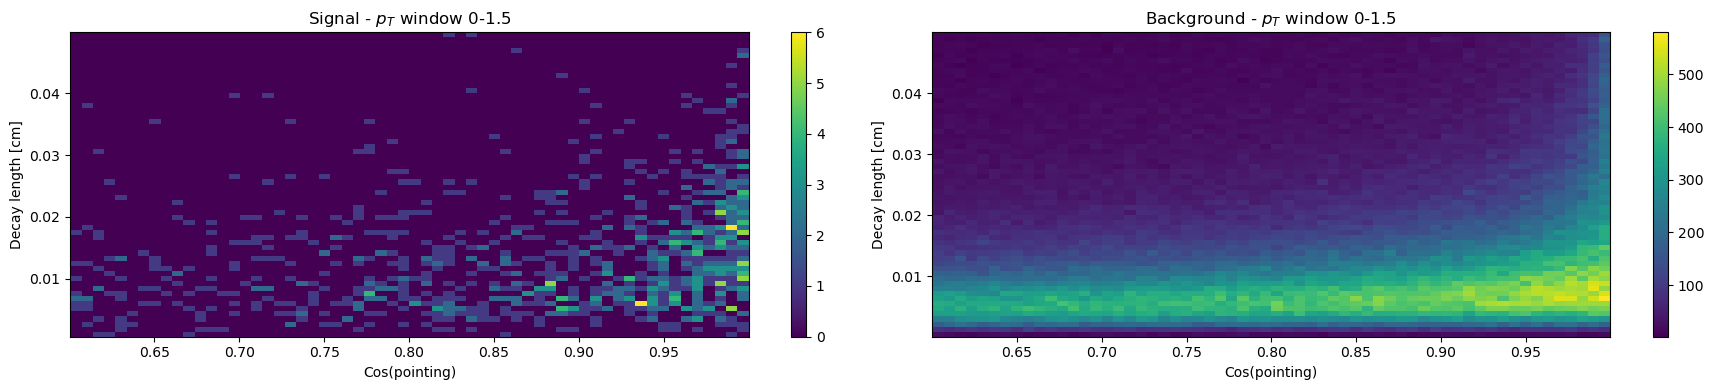

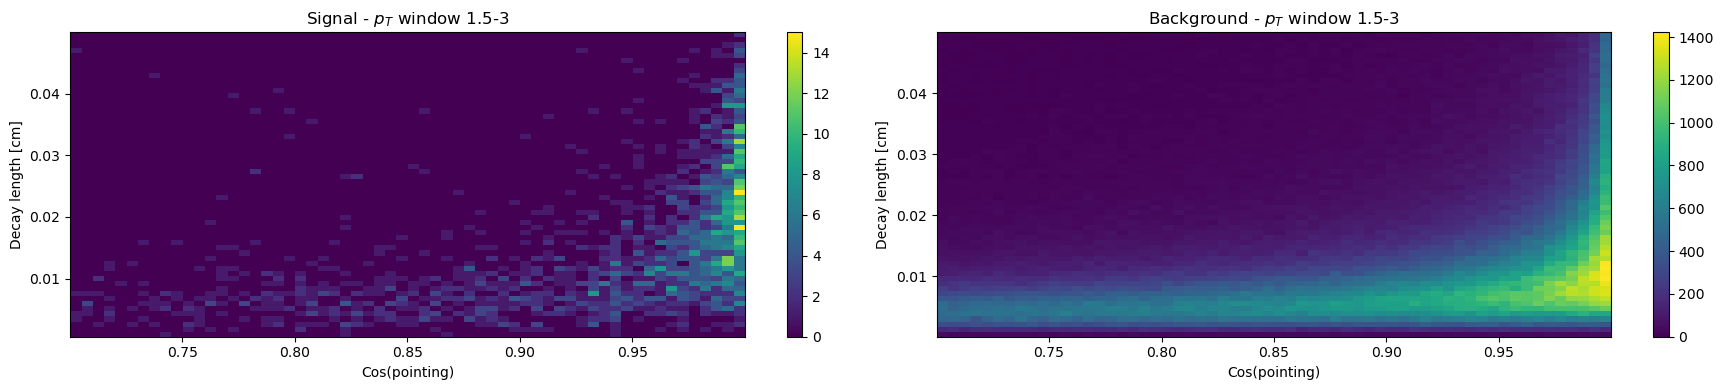

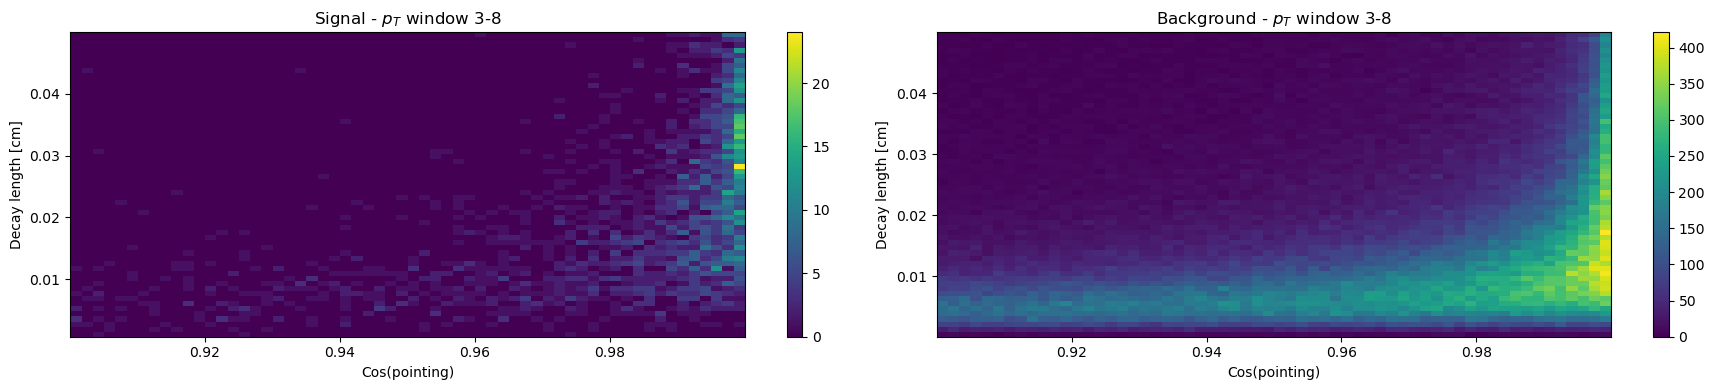

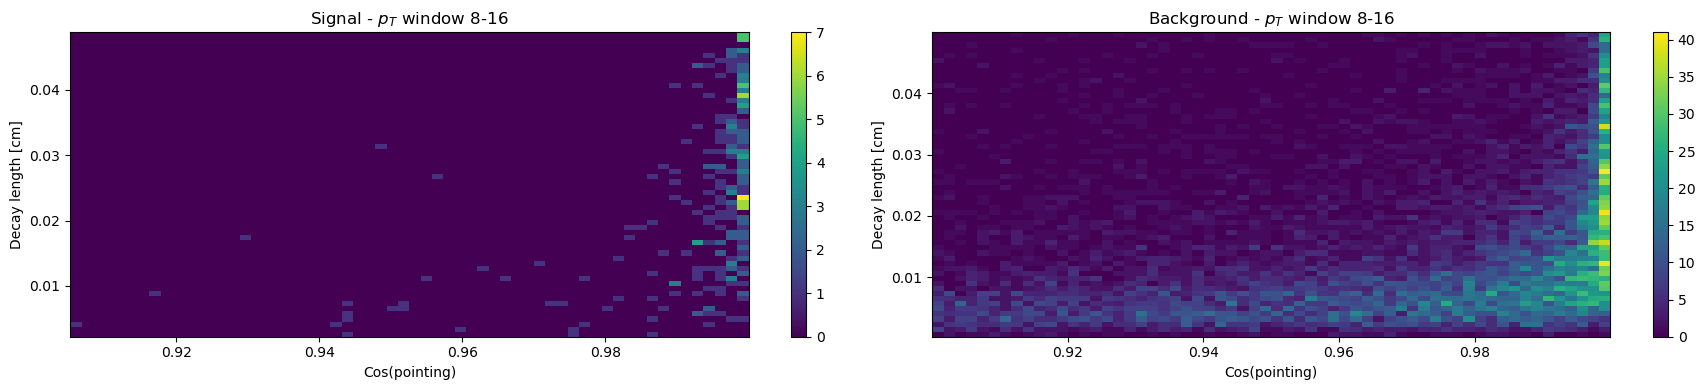

In [16]:
# choose the type of plot: "scatter", "hexbin", or "hist2d"
plot_type = "hist2d"

for i, mask_pt in enumerate(multiple_masks_pt):

    # define your two cases
    masks_cases = { "Signal" : mask_pt & mask_signal, "Background" : mask_pt & mask_background }
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    
    for ax, (label, mask) in zip(axes, masks_cases.items()):

        # CUTS TO FOCUS ON USEFUL AREAS:
        match i:   # this command is like the usual "switch" in other languages
            case 0: cut_poy = 0.6
            case 1: cut_poy = 0.7
            case _: cut_poy = 0.9
        cut_decay = 0.05
        # filter rows jointly to keep associated the two variables of a same row
        rows = final_results.loc[   mask &
                                    (final_results["cos_pointing"] > cut_poy) &
                                    (final_results["decay_length"] < cut_decay)
                                ]
        # now we extract x, y
        x = rows["cos_pointing"].values
        y = rows["decay_length"].values
        
        if plot_type == "scatter":
            ax.scatter(x, y, s=2, alpha=0.3)
        
        elif plot_type == "hexbin":
            hb = ax.hexbin(
                x, y, gridsize=50, cmap="viridis", mincnt=1
            )
            fig.colorbar(hb, ax=ax)
        
        elif plot_type == "hist2d":
            h = ax.hist2d(x, y, bins=60, cmap="viridis")
            fig.colorbar(h[3], ax=ax)
        
        ax.set_title(f"{label} - $p_T$ window {pt_windows[i]}")
        ax.set_xlabel("Cos(pointing)")
        ax.set_ylabel("Decay length [cm]")

    plt.tight_layout()
    plt.show()


### $p_T$ DISTRIBUTION

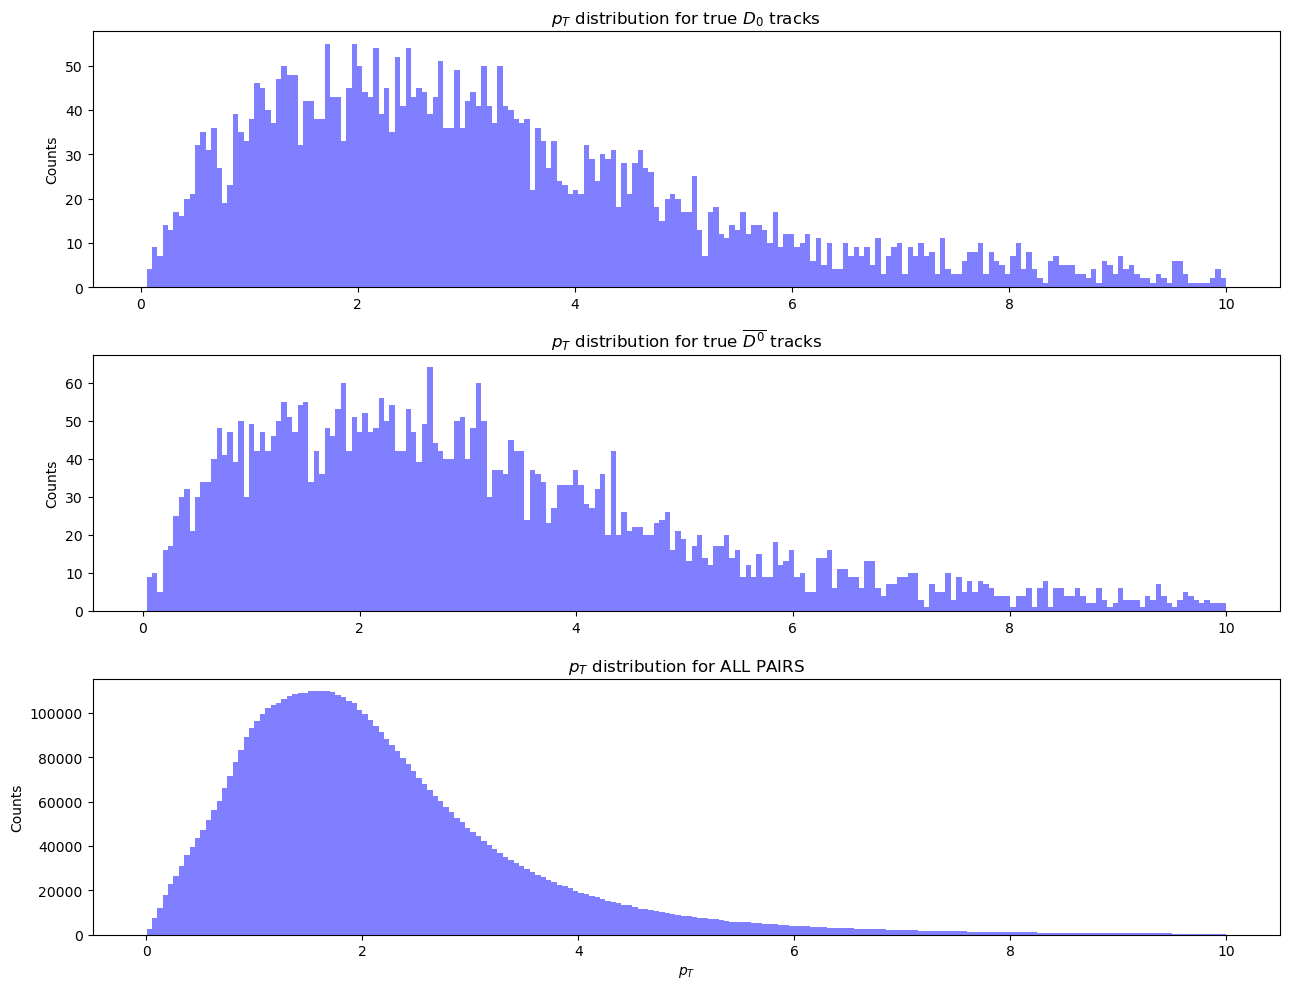

In [17]:
N_BINS = 200
fig, axs = plt.subplots(3, 1, figsize=(13, 10))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for ALL PAIRS")

plt.tight_layout()
plt.show()
del data

The $p_T$ windows like $[2-4]$, $[3-6]$ or $[3-8]$ could be useful to find the signal.

### APPLYING PAIR VARIABLES CUTS

In [18]:
# single cuts:
cut_cos_pointing = 0.96
cut_dca_product = 0.00001


# we create the cuts as a mask:
cuts = (
    (final_results['cos_pointing'] > cut_cos_pointing)
    &
    (final_results['dcaXY_product'] < cut_dca_product)
    &
    # p_t window:
    (final_results['pt'] > 2) & (final_results['pt'] < 8)
)


In [19]:
final_results = final_results[ cuts ]

---

---

---

<center><span style="font-size:35px;"><b>INVARIANT MASS FIT</b></span></center>

### INVARIANT MASS PLOT of data after cuts

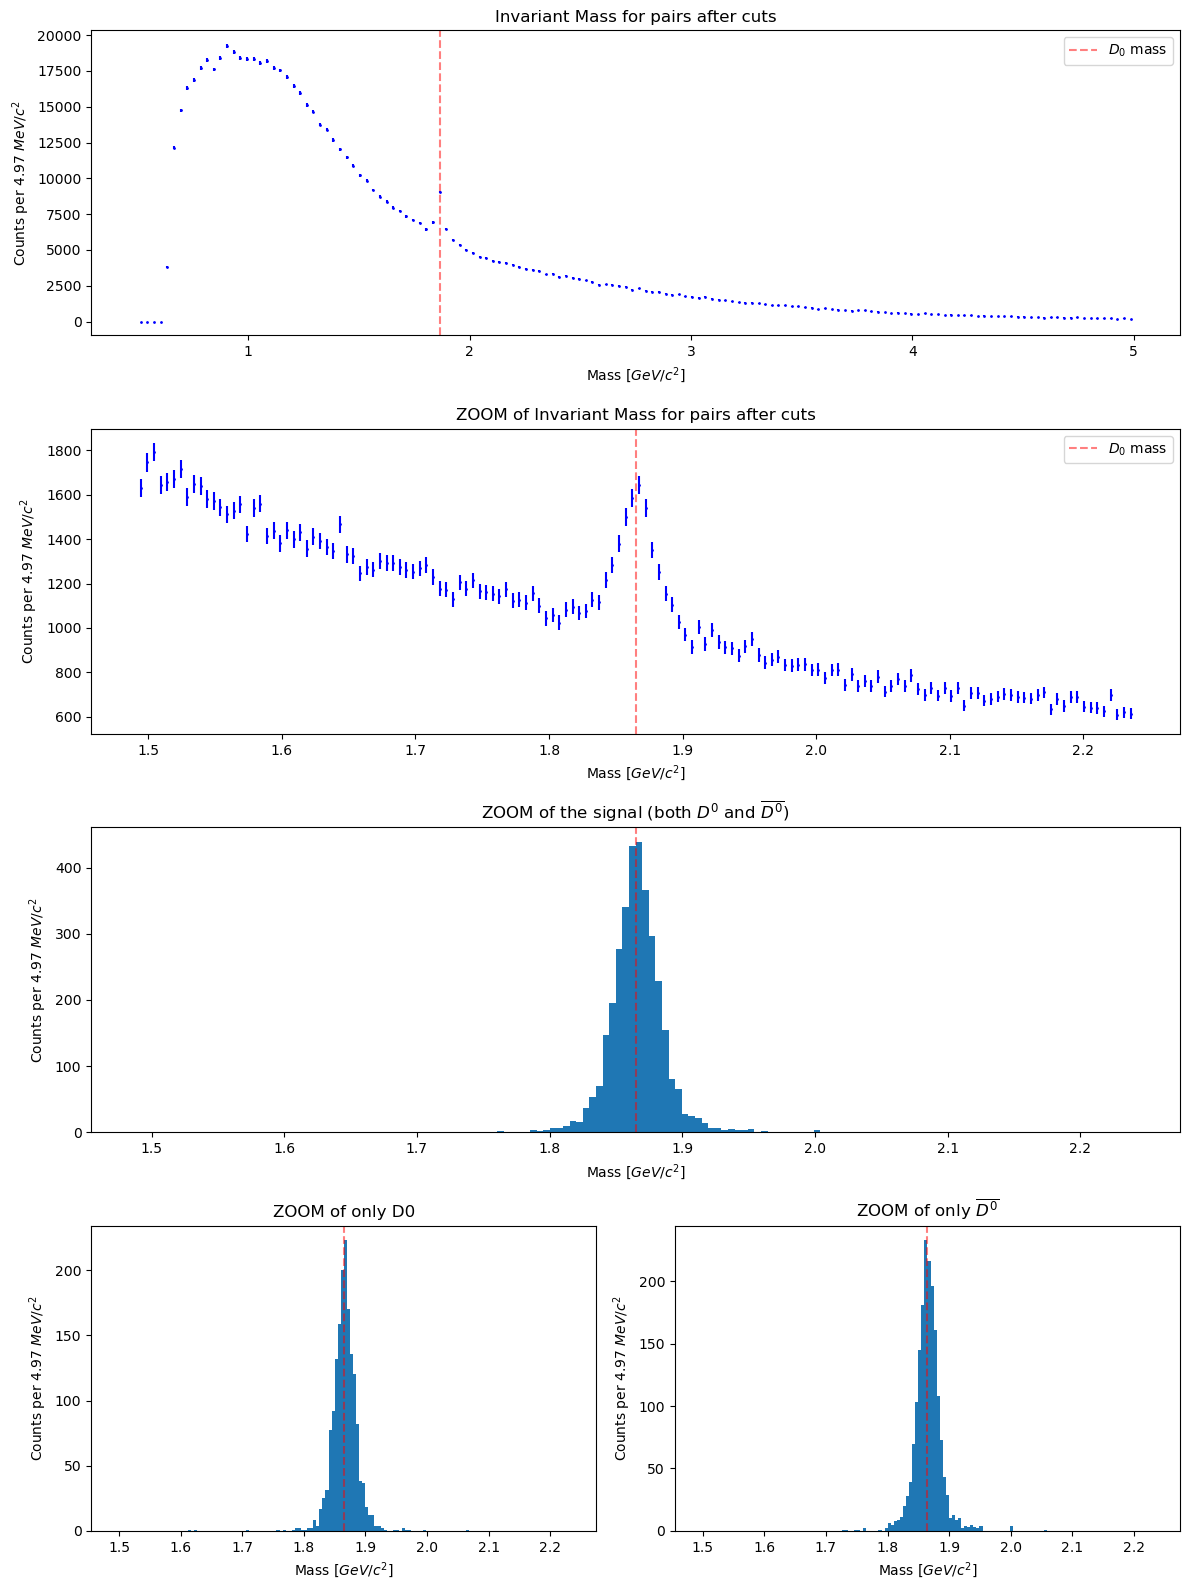

In [20]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0     # for zoom
N_BINS = 150

# Layout con due colonne
zones = [
    ["total", "total"],
    ["total_zoom", "total_zoom"],
    ["signal", "signal"],           # both D0 and anti_D0
    ["D0", "anti_D0"]
]

# Creazione della figura usando subplot_mosaic
fig, axs = plt.subplot_mosaic(
    zones,
    figsize=(12, 16),
    gridspec_kw={"width_ratios": [1, 1]}
)

# our cutted data with reflex component:---------------------------------
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate( [data_inv_mass, data_anti_mass] )

# PLOT OF ALL PAIRS
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(0.5, 5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs["total"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs["total"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs["total"].set_xlabel("Mass [$GeV/c^2$]")
axs["total"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["total"].set_title("Invariant Mass for pairs after cuts")
axs["total"].legend()

# ZOOM OF ALL PAIRS
counts, bin_edges = np.histogram(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors = np.sqrt(counts)         # poisson errors
axs["total_zoom"].errorbar(bin_centers, counts, yerr=errors, fmt='.', markersize=2, color='blue')
axs["total_zoom"].axvline(x=m_d0, color="red", ls='--', alpha=0.5, label=r"$D_0$ mass")
axs["total_zoom"].set_xlabel("Mass [$GeV/c^2$]")
axs["total_zoom"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["total_zoom"].set_title("ZOOM of Invariant Mass for pairs after cuts")
axs["total_zoom"].legend()

# out cutted and true D0 -------------------------------------------------
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )

# ZOOM OF the signal:
axs["signal"].hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["signal"].set_xlabel("Mass [$GeV/c^2$]")
axs["signal"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["signal"].set_title("ZOOM of the signal (both $D^0$ and $\overline{{D^0}}$)")

# ZOOM OF only D0
axs["D0"].hist( data_inv_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["D0"].set_title("ZOOM of only D0")

# ZOOM OF only anti_D0
axs["anti_D0"].hist( data_anti_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["anti_D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["anti_D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["anti_D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["anti_D0"].set_title("ZOOM of only $\overline{{D^0}}$")

#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

#### INFO ON THE CUTS

In [21]:
data_inv_bg  = final_results.loc[ mask_background & cuts, 'inv_mass'].values
data_anti_bg = final_results.loc[ mask_background & cuts, 'anti_mass'].values
data_bg = np.concatenate( [data_inv_bg, data_anti_bg] )

print(f"Total D0 before cuts:               {d0_tot}")
print(f"Total D0 found after cuts:          {len(data_inv_mass_true)} ---> {len(data_inv_mass_true)/d0_tot*100:.2f}% \n")
print(f"Total anti-D0 before cuts:          {anti_d0_tot}")
print(f"Total anti-D0 found after cuts:     {len(data_anti_mass_true)} ---> {len(data_anti_mass_true)/anti_d0_tot*100:.2f}% \n")
print(f"Total signal before cuts:           {signal_tot}")
print(f"Total signal found after cuts:      {len(data_inv_mass_true)+len(data_anti_mass_true)} ---> {(len(data_inv_mass_true)+len(data_anti_mass_true))/signal_tot*100:.2f}% \n")

print(f"Total background found after cuts:       ---> {len(data_bg)/num_bg_pairs*100:.2f}% \n")

# LET'S COUNT THE D0 INSIDE AN INTERVAL:
print(f"LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL): \n")
sigma_guess = 0.015
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
signal_filtered = signal[ (signal > m_d0 - 3*sigma_guess) & (signal < m_d0 + 3*sigma_guess) ]
# background:
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
bg = np.concatenate( [data_inv_mass, data_anti_mass] )
bg_filtered = bg[ (bg > m_d0 - 3*sigma_guess) & (bg < m_d0 + 3*sigma_guess) ]
print(f"Signal found in the interval:     {len(signal_filtered)}")
print(f"Background found in the interval: {len(bg_filtered)}\n")
print(f"Percentage of signal inside the interval: {len(signal_filtered)/ (len(bg_filtered) + len(signal_filtered) )*100:.2f}%")
print(f"Significance:                     {len(signal_filtered)/np.sqrt( len(bg_filtered)+ len(signal_filtered)):.2f}")
print(f"Ratio (signal/bg):                {len(signal_filtered)/len(bg_filtered):.2f}")

Total D0 before cuts:               8590
Total D0 found after cuts:          1628 ---> 18.95% 

Total anti-D0 before cuts:          9058
Total anti-D0 found after cuts:     1763 ---> 19.46% 

Total signal before cuts:           528
Total signal found after cuts:      3391 ---> 642.23% 

Total background found after cuts:       ---> 1.59% 

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL): 

Signal found in the interval:     3253
Background found in the interval: 22409

Percentage of signal inside the interval: 12.68%
Significance:                     20.31
Ratio (signal/bg):                0.15


---

# FITTING MASS

We try to fit the invariant mass histogram using:
* a gaussian for the signal
* a gaussian for the reflex component
* a linear function for the background

We do it in a way so that the ratio $N_1/N_2$ between the two gaussian is fixed, and the parameter $k$ is free:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Reflex} + \text{Signal} \right) + \text{Background}
$$

which means:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Gaussian1} + \text{Gaussian2} \right) + a \cdot x +b
$$

#### FINDING RATIO $N_1/N_2$
Let's fit the data given by signal + reflex component (using MC info).

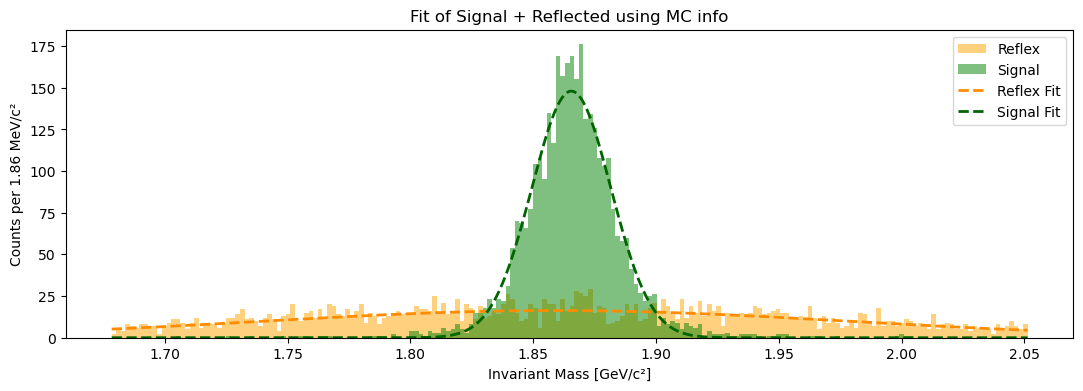

N1 value (reflex): 4.877
N1 value (signal): 5.976
Ratio N1/N2 (reflex/sign): 0.816


In [22]:
# --- Fit function: Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# Histogram of signal and reflected part data only
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & cuts, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & cuts, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )


# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
# ------- reflex component:
reflex_counts, reflex_edges, _ = ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
# poisson errors:
sigma_reflex_hist = np.sqrt(reflex_counts)
sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
sign_params = sign_fit_res[0]
mu_sign, sigma_sign = sign_params[1], sign_params[2]
k_sign = sign_params[0]
# ----
reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
reflex_params = reflex_fit_res[0]
mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
k_reflex = reflex_params[0]

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Fit of Signal + Reflected using MC info")
ax.legend()
plt.show()

# PRINT:
ratio_from_fit = k_reflex/k_sign
print(f"N1 value (reflex): {k_reflex:.3f}")
print(f"N1 value (signal): {k_sign:.3f}")
print(f"Ratio N1/N2 (reflex/sign): {ratio_from_fit:.3f}")

#### INVARIANT MASS FIT

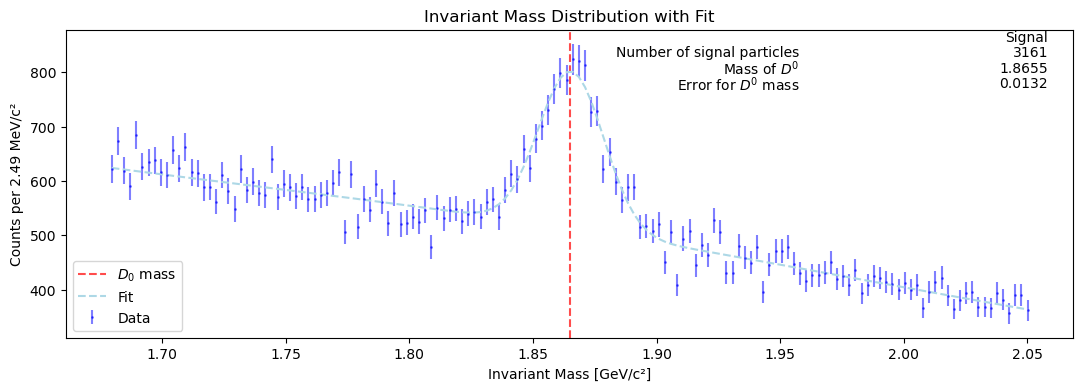

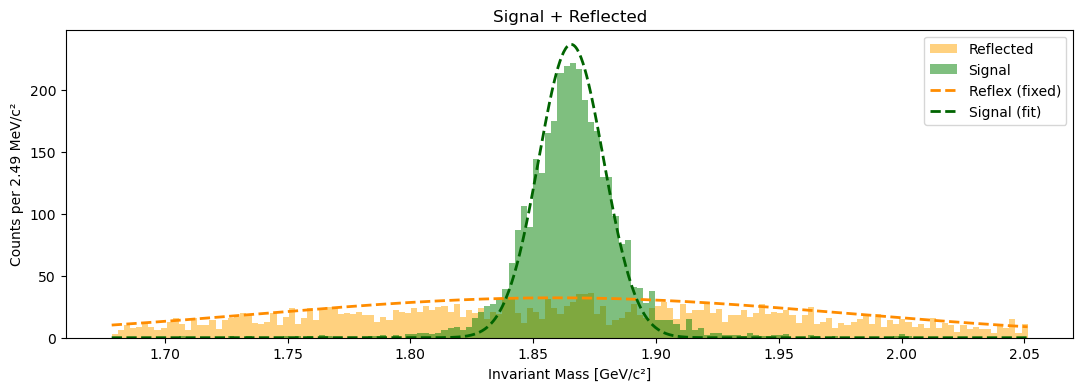

Signal Gaussian: mu = 1.865452, sigma = 0.013247
Reflex Gaussian (fixed): mu = 1.859173, sigma = 0.119332
Fitted amplitude ratio N1/N2 = 0.8161
Results of signal fit: D0 mass  1.865452        error 0.013247
Ratio N1/N2: 1.003377


In [24]:
# --- Fit function: 1 free Gaussian (signal) + 1 FIXED Gaussian (reflex) + linear background ---
ratio = ratio_from_fit   # fixed ratio from previous fit N_signal/N_reflex

def fit_function(x, k, mu1, sigma1, a, b):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    background   = a*x + b
    return k * ( ratio*reflex_part + signal_part) + background


# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 150
binsize = (MAX_MASS - MIN_MASS)/N_BINS

# Initial parameter guesses
k_param       = 100
signal_params = [m_d0, 0.02]
back_params   = [133, 1000]

# --- Data ---
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate([data_inv_mass, data_anti_mass])

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
both_counts, both_edges = np.histogram(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)
# plot:
ax.errorbar(both_centers, both_counts, yerr=sigma_hist, fmt='.', markersize=2, color='blue', alpha=0.5, label='Data')
ax.axvline(x=m_d0, color="red", ls='--', label=r"$D_0$ mass", alpha=0.7)

# FIT:
both_fit_res = curve_fit(
    f       = fit_function,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,                # 0: k
        signal_params[0],       # 1: mu1
        signal_params[1],       # 2: sigma1
        back_params[0],         # 3: a
        back_params[1]          # 4: b
    ]
)

both_params = both_fit_res[0]
k_fit, mu1, sigma1, a_fit, b_fit = both_params

# PLOT fitted curve:
ax.plot( both_centers, fit_function(both_centers, *both_params),
    color='lightblue', linestyle='dashed', linewidth=1.5, label='Fit'
)

# COUNT of D0 from the signal Gaussian only:
mass_from_fit  = mu1
sigma_from_fit = sigma1
counts_from_fit =  ( k_fit * ratio * (norm.cdf(MAX_MASS, loc=mu1, scale=sigma1) - norm.cdf(MIN_MASS, loc=mu1, scale=sigma1)) ) / binsize

# TABLE INSIDE PLOT:
ax.table(
    cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
    rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
    colLabels = ['Signal'],
    colLoc = "right",
    bbox = [0.75, 0.8, 0.25, 0.2],
    edges = 'open',
    rowLoc = 'right'
)

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Invariant Mass Distribution with Fit")
ax.legend(loc='lower left')
plt.show()

# ---------------------------------------------------------------------------------------
# SECOND PLOT: signal and reflected plot with fixed Gaussian for reflex

fig, ax = plt.subplots(figsize=(13,4))

# DATASETS:
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & cuts, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & cuts, 'inv_mass'].values
reflex_data = np.concatenate([data_inv_mass_true_ref, data_anti_mass_true_ref])
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal_data = np.concatenate([data_inv_mass_true, data_anti_mass_true])
# Histograms
ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='orange', alpha=0.5, label='Reflected')
ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        color='green', alpha=0.5, label='Signal')

# FITTED CURVES:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
# Fixed reflex Gaussian
ax.plot(x_fit, k_fit * norm.pdf(x_fit, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex (fixed)')
# Signal Gaussian
ax.plot(x_fit, k_fit * ratio * norm.pdf(x_fit, mu1, sigma1), '--', color='darkgreen', linewidth=2, label='Signal (fit)')

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Signal + Reflected")
ax.legend()
plt.show()

print(f"Signal Gaussian: mu = {mu1:.6f}, sigma = {sigma1:.6f}")
print(f"Reflex Gaussian (fixed): mu = {mu_reflex:.6f}, sigma = {sigma_reflex:.6f}")
print(f"Fitted amplitude ratio N1/N2 = {ratio:.4f}")

print(f"Results of signal fit: D0 mass  {mass_from_fit:3f}        error {sigma_from_fit:3f}")
print(f"Ratio N1/N2: {mu1/mu_reflex:3f}")

In [25]:
print(f"True number of signal particles:     {len(signal_filtered)}")
print(f"Expected number of signal particles: {counts_from_fit:.0f}")

True number of signal particles:     3253
Expected number of signal particles: 3161


In [26]:
from tqdm.notebook import tqdm

ModuleNotFoundError: No module named 'tqdm'

correzione ipotesi:
```
# NEW : Assign particle nature hypothesis based on the chosen cuts
        mask_both = df_trackextr.eval(f"({Ka_hyp} & {Pi_hyp})")
        mask_Ka = df_trackextr.eval(Ka_hyp)
        mask_Pi = df_trackextr.eval(Pi_hyp)
        # From the documentation of numpy select:
        # numpy.select(condlist, choicelist, default=0) When multiple conditions are satisfied, the first one encountered in condlist is used.
        df_trackextr["Hyp"] = np.select([mask_both, mask_Ka, mask_Pi], ["Both", "Kaon", "Pion"], default="Bkg")
        mask = mask_Ka | mask_Pi        # create boolean mask
        # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
        df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge", "fDcaXY",
                                               "Hyp", "fPosX", "fPosY", "fPosZ", "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTOFpi", "fNsigmaTOFka"] ]
    
```